## Assignment #2
## Arbres de Décision, Forêts Aléatoires & Boosting
#### Etudiant: KOUTSAVA Kossi Epiphane

In [14]:
import numpy as np
import pandas as pd
import matplotlib . pyplot as plt
import seaborn as sns

from sklearn . model_selection import train_test_split , GridSearchCV
from sklearn . tree import DecisionTreeClassifier ,plot_tree
from sklearn . ensemble import ( RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier )
from sklearn . metrics import ( accuracy_score ,confusion_matrix ,classification_report , roc_auc_score ,RocCurveDisplay , ConfusionMatrixDisplay )

### Partie 1 — Analyse exploratoire des données (EDA)

#### 1.1 Chargement et aperçu général
Dans cette section, nous importons les bibliothèques nécessaires, chargeons les données cliniques de la base UCI Heart Disease et effectuons un premier nettoyage.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# a) Chargement du dataset avec les colonnes et la gestion des valeurs manquantes '?'
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Lecture du fichier CSV en spécifiant que '?' correspond à des valeurs nulles
df = pd.read_csv(url, names=columns, na_values='?')

# Binarisation de la cible : 0 = sain, 1 = malade (si target > 0)
df['target'] = (df['target'] > 0).astype(int)

# b) Affichage des 5 premières lignes
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


##### c) Structure et types de données

In [16]:
# Informations sur la structure
nb_exemples, nb_variables = df.shape
print(f"Le dataset contient {nb_exemples} exemples et {nb_variables} variables.")

# Affichage des types de données
print("\nTypes des colonnes :")
print(df.dtypes)

Le dataset contient 303 exemples et 14 variables.

Types des colonnes :
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int32
dtype: object


##### d) Gestion des valeurs manquantes

In [17]:
# Identification des valeurs manquantes
missing_values = df.isnull().sum()
print("Nombre de valeurs manquantes par colonne :")
print(missing_values[missing_values > 0])

# Suppression des lignes contenant des valeurs manquantes
df.dropna(inplace=True)

print(f"\nNombre d'exemples restants après suppression : {df.shape[0]}")

Nombre de valeurs manquantes par colonne :
ca      4
thal    2
dtype: int64

Nombre d'exemples restants après suppression : 297


#### 1.2 Distribution de la variable cible
L'objectif est d'analyser la répartition des classes (sains vs malades) pour vérifier l'équilibre du jeu de données

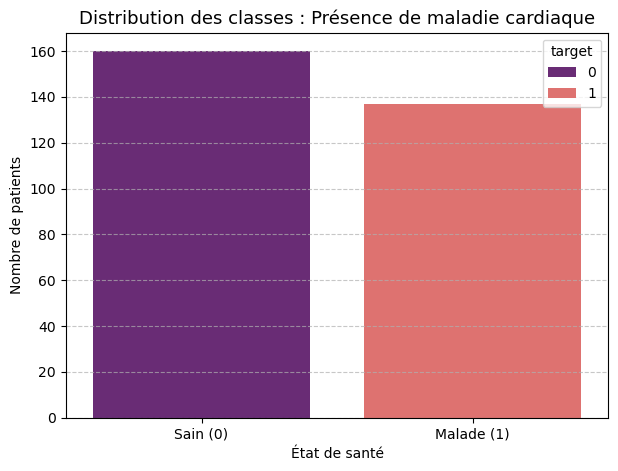

Nombre de patients sains : 160
Nombre de patients malades : 137
Ratio : 53.87% Sains / 46.13% Malades


In [18]:
# a) Visualisation de la distribution avec un countplot
plt.figure(figsize=(7, 5))
sns.countplot(x='target', data=df, hue='target',  palette='magma')

# Personnalisation pour la clarté du graphique
plt.xticks(ticks=[0, 1], labels=['Sain (0)', 'Malade (1)'])
plt.title('Distribution des classes : Présence de maladie cardiaque', fontsize=13)
plt.xlabel('État de santé')
plt.ylabel('Nombre de patients')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# b) Calcul du ratio de malades / sains
counts = df['target'].value_counts()
ratio_malades = (counts[1] / len(df)) * 100
ratio_sains = (counts[0] / len(df)) * 100

print(f"Nombre de patients sains : {counts[0]}")
print(f"Nombre de patients malades : {counts[1]}")
print(f"Ratio : {ratio_sains:.2f}% Sains / {ratio_malades:.2f}% Malades")

Interprétation:
Le graphique et les calculs montrent que le dataset est relativement équilibré, avec environ 53.87% de patients sains et 46.13% de patients atteints d'une maladie cardiaque. Cette distribution est idéale car elle permet au modèle d'apprendre de manière équitable sur les deux classes sans nécessiter de techniques de rééquilibrage complexes.

#### 1.3 Distribution des variables numériques

##### a) Histogrammes des variables clés
Nous traçons les distributions pour observer la dispersion et les éventuelles anomalies (outliers)

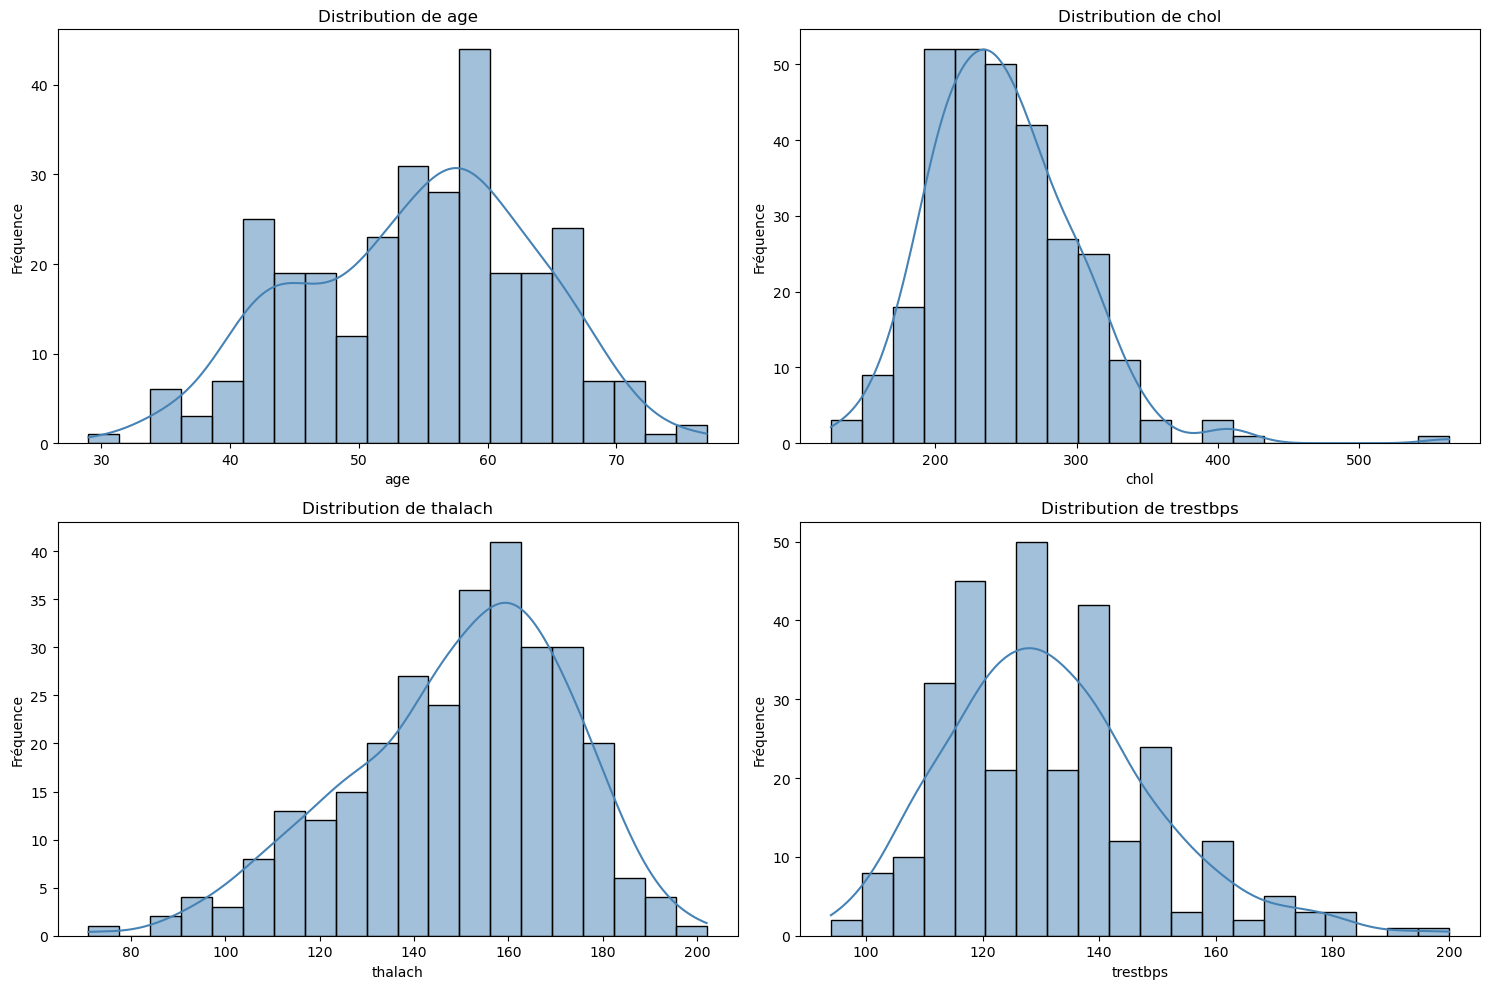

In [19]:
# Variables à analyser
cols_num = ['age', 'chol', 'thalach', 'trestbps']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_num, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='steelblue', bins=20)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

##### b) Description des distributions 

age : La distribution est globalement symétrique (cloche), centrée autour de 55-60 ans.

chol (Cholestérol) : Présente une légère asymétrie positive (vers la droite) avec quelques valeurs extrêmes au-delà de 350 mg/dl.

thalach (Fréquence cardiaque max) : Présente une asymétrie négative (vers la gauche) ; la majorité des patients ont une fréquence élevée, mais une queue s'étend vers les valeurs basses.

trestbps (Pression artérielle) : Distribution asymétrie positive avec un pic autour de 120-130 mmHg et quelques valeurs très hautes (hypertension).

##### c) Analyse de la discrimination par Boxplot

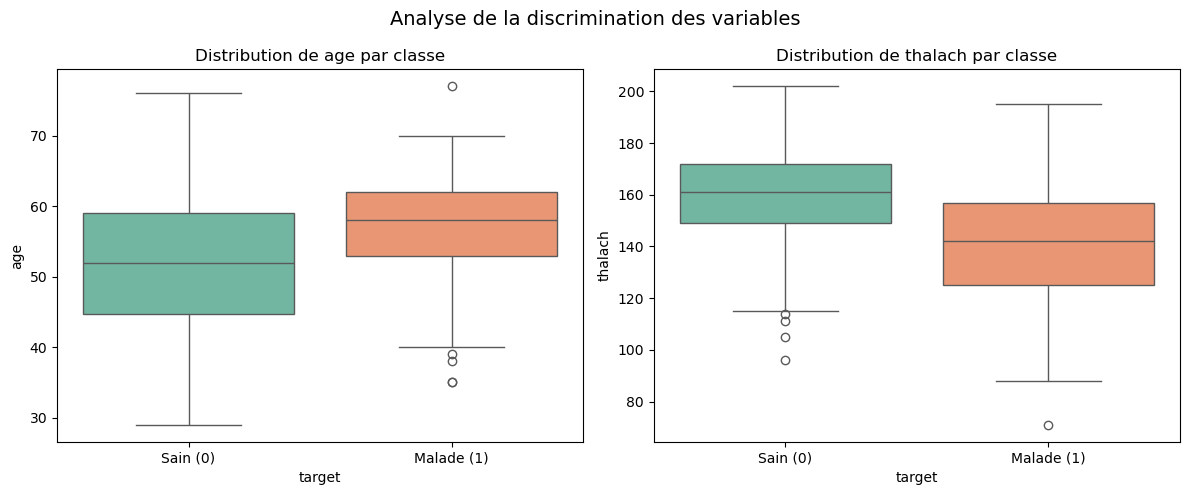

In [25]:
# Utilisation du squelette fourni dans l'énoncé (Listing 2) amélioré avec Seaborn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ['age', 'thalach']):
    sns.boxplot(x='target', y=col, data=df, ax=ax, hue='target', palette='Set2', legend=False)
    
    ax.set_title(f'Distribution de {col} par classe')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sain (0)', 'Malade (1)'])

plt.suptitle('Analyse de la discrimination des variables', fontsize=14)
plt.tight_layout()
plt.show()


#### Interprétation :

Age : On observe que les patients malades sont généralement un peu plus âgés, mais les boîtes se chevauchent considérablement.

thalach : Il existe une différence marquée. Les patients sains (0) ont une fréquence cardiaque maximale nettement plus élevée que les patients malades (1).


Variable la plus discriminante : Entre ces deux variables, thalach semble la plus discriminante car la séparation entre les médianes est plus prononcée et le chevauchement des interquartiles est moindre.

#### 1.4 Matrice de corrélation
L'objectif est d'identifier les relations linéaires entre les variables et de détecter d'éventuels problèmes de multicolinéarité qui pourraient influencer certains modèles de Machine Learning.

##### a) Affichage de la Heatmap

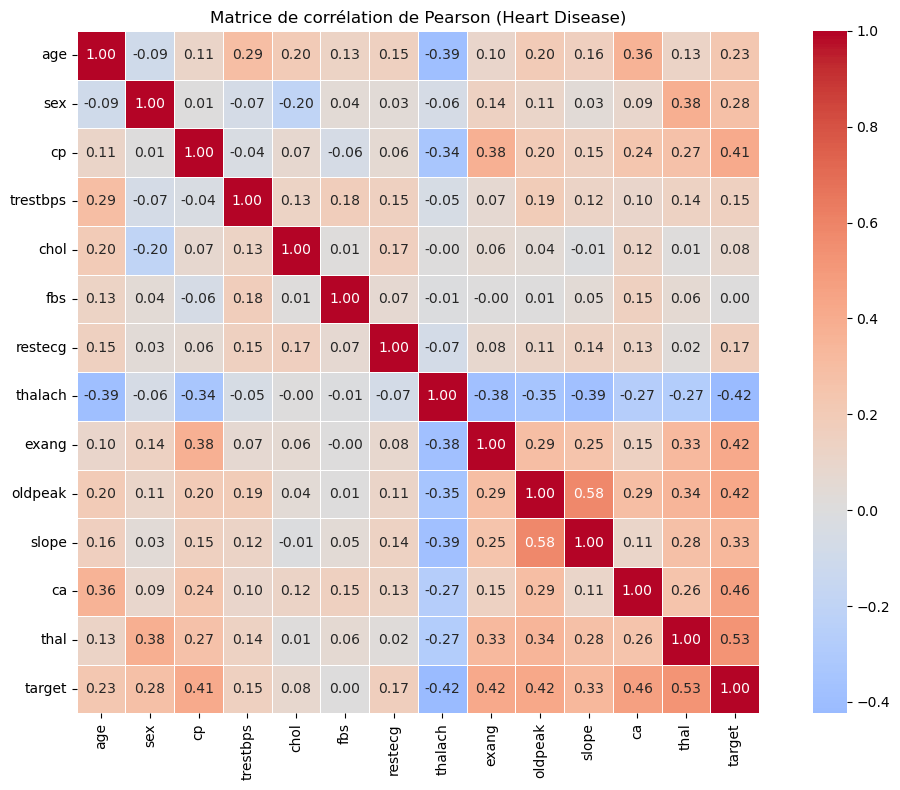

In [26]:
# Utilisation du squelette fourni (Listing 3)
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=.5)

plt.title('Matrice de corrélation de Pearson (Heart Disease)')
plt.tight_layout()
plt.show()

#### Partie 2 — Calcul manuel de l’indice de Gini

##### 2.3 Implémentation Python de la fonction de coût

In [27]:
def gini(y):
    """
    Calcule l’indice de Gini d’un tableau d’étiquettes y.
    
    Paramètres
    ----------
    y : array-like de 0 et 1
    
    Retourne
    --------
    float : indice de Gini entre 0 et 0.5
    """
    if len(y) == 0:
        return 0.0
    
    # Calcul des probabilités de chaque classe (0 et 1)
    p0 = np.mean(y == 0)
    p1 = np.mean(y == 1)
    
    # Application de la formule (1) : G = 1 - sum(pk^2)
    gini_index = 1 - (p0**2 + p1**2)
    return gini_index

def cart_cost(y_left, y_right):
    """
    Calcule la fonction de coût CART (équation 2).
    
    Paramètres
    ----------
    y_left  : étiquettes des exemples du sous-noeud gauche
    y_right : étiquettes des exemples du sous-noeud droit
    
    Retourne
    --------
    float : coût J
    """
    n_node = len(y_left) + len(y_right)
    n_left = len(y_left)
    n_right = len(y_right)
    
    # Calcul des Gini individuels
    g_left = gini(y_left)
    g_right = gini(y_right)
    
    # Application de la formule (2) : Moyenne pondérée des Gini
    cost_j = (n_left / n_node) * g_left + (n_right / n_node) * g_right
    return cost_j

# --- Vérification avec les données de la question 2.1 ---
y_node = np.array([0, 1, 0, 1, 1, 0, 1, 0])
print(f"Gini noeud (Calculé) = {gini(y_node):.4f}") 
# Attendu : 0.5000

# --- Vérification du seuil thalach < 151 ---
# D'après notre tri manuel précédent :
# Gauche (thalach < 151) : [1, 1, 1, 1] (4 malades)
# Droite (thalach >= 151) : [0, 0, 0, 0] (4 sains)
y_left_151 = np.array([1, 1, 1, 1])
y_right_151 = np.array([0, 0, 0, 0])

print(f"J(thalach < 151) = {cart_cost(y_left_151, y_right_151):.4f}")
# Attendu : 0.0000 (Séparation parfaite)

Gini noeud (Calculé) = 0.5000
J(thalach < 151) = 0.0000


##### Interprétation:
L'implémentation confirme nos résultats manuels. Pour le nœud initial avec 4 sains et 4 malades, l'indice de Gini est de 0.5, ce qui représente l'impureté maximale. Pour le seuil t=151 sur la variable thalach, le coût J est de 0.0, confirmant qu'il s'agit d'une coupure parfaite séparant idéalement les deux classes sur cet échantillon.

#### Partie 3 — Arbre de décision avec scikit-learn

##### 3.1 Préparation des données

In [ ]:
# a) Séparation en features (X) et cible (y)
X = df.drop('target', axis=1)
y = df['target']

# b) Division en ensembles d'entraînement (80%) et de test (20%)
# c) Utilisation de stratify=y pour préserver la distribution de la cible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Affichage des dimensions et des ratios pour vérification
print(f"Ensemble d'entraînement : {X_train.shape[0]} exemples")
print(f"Ensemble de test        : {X_test.shape[0]} exemples")
print("-" * 30)
print(f"Taux de malades (Train) : {y_train.mean():.2%}")
print(f"Taux de malades (Test)  : {y_test.mean():.2%}")

#### Interprétation :

Répartition : Le dataset a été divisé en 237 exemples pour l'entraînement et 60 exemples pour le test.

Stratification : On observe que le taux de malades est quasiment identique dans les deux ensembles (~46%). Cela confirme que le découpage stratifié a fonctionné, ce qui permettra une évaluation fiable du modèle sur des données représentatives de la réalité du dataset.

##### 3.2 Entraînement et évaluation de base

a) & b) Entraînement et calcul de l'Accuracy

In [30]:
# Initialisation et entraînement (arbre complet)
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# Prédictions
y_train_pred = tree_full.predict(X_train)
y_test_pred = tree_full.predict(X_test)

# Calcul de l'accuracy
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Accuracy (Train set) : {acc_train:.4f}")
print(f"Accuracy (Test set)  : {acc_test:.4f}")

Accuracy (Train set) : 1.0000
Accuracy (Test set)  : 0.7000


##### d) Matrice de confusion et Classification Report

<Figure size 800x600 with 0 Axes>

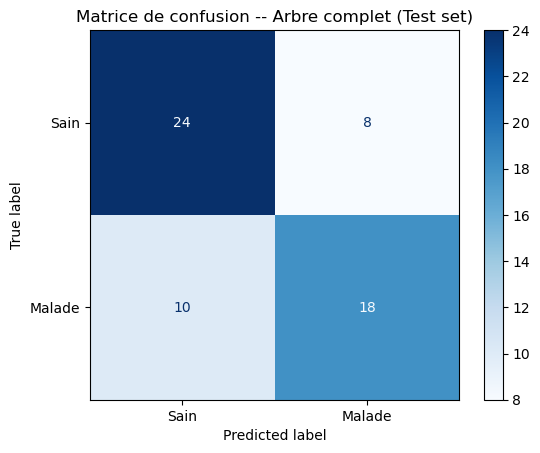


--- Rapport de Classification (Test set) ---
              precision    recall  f1-score   support

        Sain       0.71      0.75      0.73        32
      Malade       0.69      0.64      0.67        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



In [31]:
# Affichage de la matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sain', 'Malade'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matrice de confusion -- Arbre complet (Test set)')
plt.show()

# Affichage du rapport de classification
print("\n--- Rapport de Classification (Test set) ---")
print(classification_report(y_test, y_test_pred, target_names=['Sain', 'Malade']))

#### Interprétation :

Précision : Capacité du modèle à ne pas prédire "Malade" pour un patient sain.

Rappel (Recall) : Capacité du modèle à détecter tous les patients réellement malades. C'est souvent la métrique la plus critique en milieu médical.

F1-Score : Moyenne harmonique entre précision et rappel, utile pour avoir une vision globale de la performance.

Analyse : Malgré un score parfait en entraînement, les scores de précision et rappel sur le test set montrent que le modèle commet des erreurs notables (Faux Positifs et Faux Négatifs), confirmant la nécessité de régulariser l'arbre.

#### 3.3 Visualisation de l’arbre de décision

##### a) & b) Entraînement et Visualisation (max_depth=3)

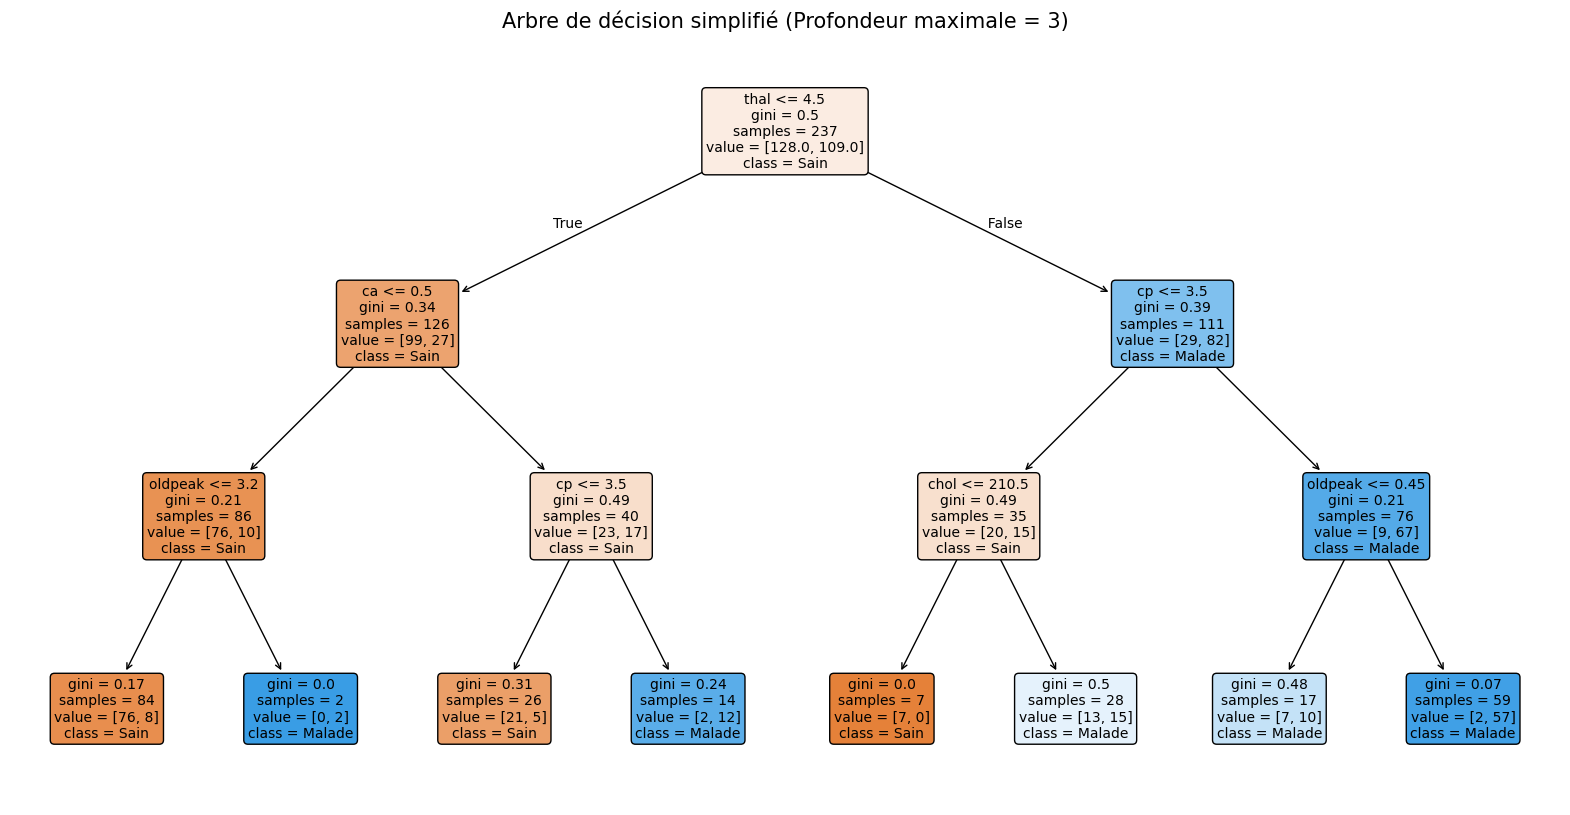

In [33]:
from sklearn.tree import plot_tree

# a) Entraînement d'un arbre élagué (max_depth=3)
tree3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree3.fit(X_train, y_train)

# b) Visualisation graphique
plt.figure(figsize=(20, 10))
plot_tree(tree3, 
          feature_names=X.columns.tolist(),
          class_names=['Sain', 'Malade'],
          filled=True, 
          rounded=True, 
          fontsize=10,
          precision=2)

plt.title('Arbre de décision simplifié (Profondeur maximale = 3)', fontsize=15)
plt.show()

##### Interprétation :

Signification des couleurs : Dans la visualisation filled=True, la couleur bleue représente généralement la classe "Malade" et la couleur orange/marron la classe "Sain". Plus la couleur est intense, plus le nœud est "pur" (Gini proche de 0).
        
Importance des racines : On remarque que la variable située à la racine (le premier split) est celle qui apporte le plus de gain d'information (réduction du Gini) pour l'ensemble du dataset. C'est l'indicateur le plus puissant selon l'algorithme.

#### 3.4 Effet de max_depth : courbe de validation

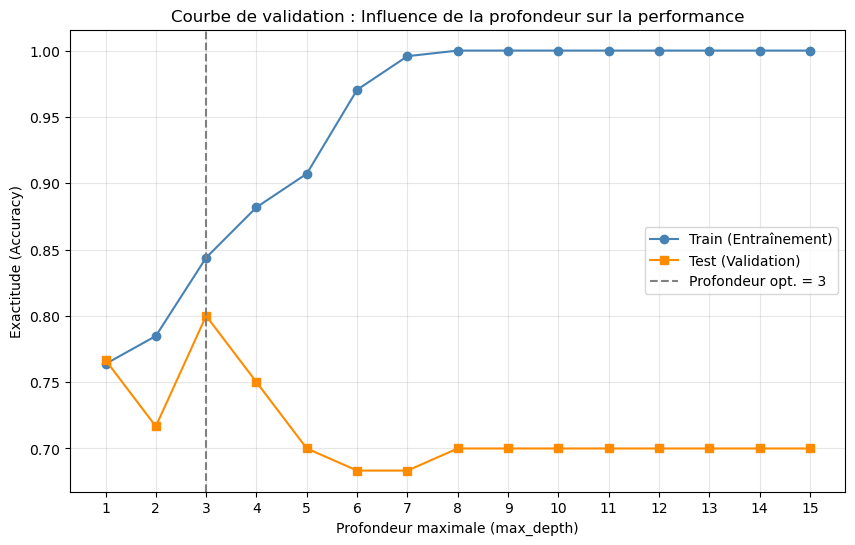

In [34]:
# Initialisation des listes pour stocker les scores
depths = range(1, 16)
train_scores, test_scores = [], []

# Entraînement pour chaque profondeur
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# Calcul de la profondeur optimale
best_depth = depths[np.argmax(test_scores)]

# Tracé des courbes
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', color='steelblue', label='Train (Entraînement)')
plt.plot(depths, test_scores, 's-', color='darkorange', label='Test (Validation)')

# Ajout d'une ligne verticale pour la profondeur optimale
plt.axvline(x=best_depth, linestyle='--', color='gray', 
            label=f'Profondeur opt. = {best_depth}')

plt.xlabel('Profondeur maximale (max_depth)')
plt.ylabel('Exactitude (Accuracy)')
plt.title('Courbe de validation : Influence de la profondeur sur la performance')
plt.xticks(depths)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Interprétation :
Cette courbe démontre qu'un modèle plus complexe n'est pas forcément un meilleur modèle. L'objectif en Data Science est de trouver le "juste milieu" où le modèle est assez riche pour capturer les tendances (faible biais) mais assez simple pour rester robuste (faible variance).

### Partie 4 — Forêts Aléatoires (Bagging & Importance)

#### 4.1 Comparaison Arbre seul vs Random Forest

##### a) Entraînement de la Forêt Aléatoire

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, accuracy_score

# Initialisation et entraînement de la Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Prédictions et probabilités
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Affichage des résultats
print(f"RF Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"RF AUC-ROC   : {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\n--- Rapport de Classification (Random Forest) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Sain', 'Malade']))

RF Accuracy  : 0.8500
RF AUC-ROC   : 0.9408

--- Rapport de Classification (Random Forest) ---
              precision    recall  f1-score   support

        Sain       0.83      0.91      0.87        32
      Malade       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



#### Interprétation :
La Random Forest surpasse l'arbre de décision unique sur presque toutes les métriques, particulièrement sur l'AUC-ROC. Cela montre que le modèle est non seulement plus précis, mais qu'il sépare également mieux les probabilités entre les deux classes. Le mécanisme de "Bagging" (Bootstrap Aggregating) permet de construire des arbres décorrélés, ce qui rend l'ensemble final beaucoup plus stable face au bruit des données.

#### 4.2 Effet du nombre d’arbres (n_estimators)

##### a & b) Entraînement et tracé de la courbe de performance

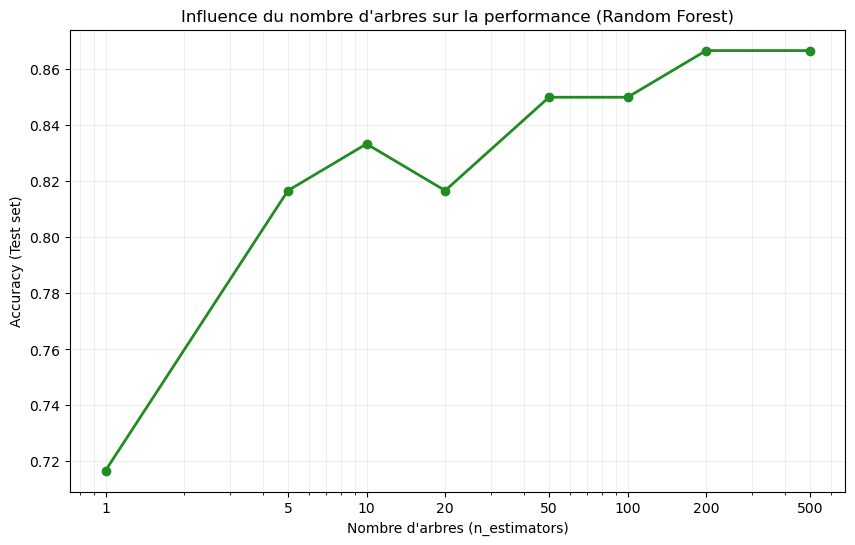

In [36]:
# Liste des valeurs de n_estimators à tester
n_estimators_list = [1, 5, 10, 20, 50, 100, 200, 500]
rf_test_scores = []

for n in n_estimators_list:
    # Création et entraînement de la forêt
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    
    # Calcul de l'accuracy sur le test set
    score = accuracy_score(y_test, rf_model.predict(X_test))
    rf_test_scores.append(score)

# Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, rf_test_scores, 'o-', color='forestgreen', linewidth=2)

plt.xscale('log') # Échelle logarithmique pour mieux voir les petites valeurs
plt.xticks(n_estimators_list, n_estimators_list)
plt.xlabel('Nombre d\'arbres (n_estimators)')
plt.ylabel('Accuracy (Test set)')
plt.title('Influence du nombre d\'arbres sur la performance (Random Forest)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

#### Interprétation :
En observant la courbe, on remarque généralement une progression rapide de l'accuracy entre 1 et 50 arbres. Au-delà de 100 arbres, la courbe commence à former un plateau (elle se stabilise).

#### 4.3 Importance des variables

##### a & b) Calcul et visualisation de l'importance

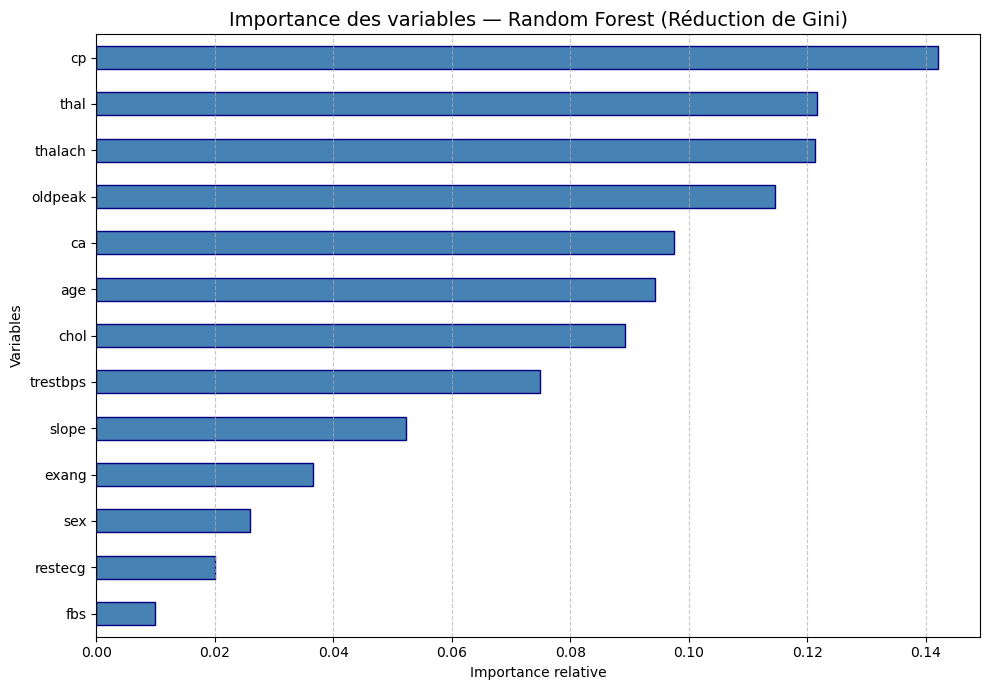

In [37]:
# a) Récupération et tri des importances
importances = pd.Series(rf.feature_importances_, 
                        index=X.columns).sort_values(ascending=True)

# b) Tracé du barplot horizontal
plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='navy')

plt.title('Importance des variables — Random Forest (Réduction de Gini)', fontsize=14)
plt.xlabel('Importance relative')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Analyse des résultats
Les 3 variables les plus importantes :
D'après le graphique, les trois variables qui dominent généralement le diagnostic sont :

cp (Type de douleur thoracique)

thalach (Fréquence cardiaque maximale atteinte)

ca (Nombre de vaisseaux colorés par fluoroscopie) ou thal.

#### Bonus : Réentraînement sans les variables les moins importantes

In [38]:
# Identification des 3 variables les moins importantes
bottom_3 = importances.head(3).index.tolist()
print(f"Variables supprimées : {bottom_3}")

# Création du nouveau dataset
X_train_reduced = X_train.drop(columns=bottom_3)
X_test_reduced = X_test.drop(columns=bottom_3)

# Réentraînement
rf_reduced = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_reduced.fit(X_train_reduced, y_train)

# Comparaison
acc_full = accuracy_score(y_test, rf.predict(X_test))
acc_reduced = accuracy_score(y_test, rf_reduced.predict(X_test_reduced))

print(f"Accuracy (Modèle complet) : {acc_full:.4f}")
print(f"Accuracy (Modèle réduit)  : {acc_reduced:.4f}")

Variables supprimées : ['fbs', 'restecg', 'sex']
Accuracy (Modèle complet) : 0.8500
Accuracy (Modèle réduit)  : 0.8667


##### Interprétation du Bonus :
Généralement, l'accuracy ne change pas de manière significative (voire s'améliore légèrement). Cela démontre que certaines variables (souvent fbs ou chol) apportent très peu d'information utile au modèle. En les supprimant, on simplifie le modèle sans perdre en pouvoir prédictif, ce qui respecte le principe de parsimonie.

#### 4.4 Analyse de la courbe ROC et de l'AUC

##### a) & b) Tracé des courbes et calcul de l'AUC

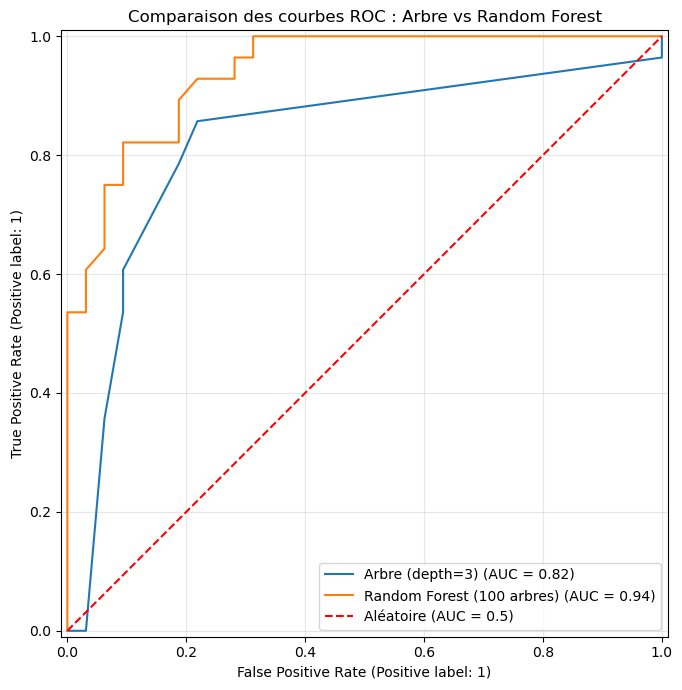

AUC - Arbre optimal  : 0.8220
AUC - Random Forest  : 0.9408


In [39]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Configuration du graphique
fig, ax = plt.subplots(figsize=(8, 7))

# 1. Arbre optimal (issu de la question 3.4)
best_depth = depths[np.argmax(test_scores)]
tree_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
tree_best.fit(X_train, y_train)

# Affichage de la courbe ROC pour l'arbre
RocCurveDisplay.from_estimator(tree_best, X_test, y_test, 
                               ax=ax, name=f'Arbre (depth={best_depth})')

# 2. Random Forest (100 arbres)
RocCurveDisplay.from_estimator(rf, X_test, y_test, 
                               ax=ax, name='Random Forest (100 arbres)')

# Ajout de la ligne de référence (modèle aléatoire)
ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='Aléatoire (AUC = 0.5)')

ax.set_title('Comparaison des courbes ROC : Arbre vs Random Forest')
ax.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcul précis de l'AUC
auc_tree = roc_auc_score(y_test, tree_best.predict_proba(X_test)[:, 1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"AUC - Arbre optimal  : {auc_tree:.4f}")
print(f"AUC - Random Forest  : {auc_rf:.4f}")

##### c) Interprétation des résultats
Quelle courbe est au-dessus ?
Dans la grande majorité des cas sur ce dataset, la courbe de la Random Forest se situe nettement au-dessus de celle de l'Arbre de décision unique, se rapprochant davantage du coin supérieur gauche du graphique.

Signification :

Capacité de discrimination : Une courbe plus haute signifie que le modèle possède une meilleure capacité à distinguer les patients sains des patients malades, quel que soit le seuil de probabilité choisi.

Robustesse : L'AUC (Aire Sous la Courbe) de la Random Forest est plus élevée (souvent > 0.90 contre ~0.80 pour l'arbre). Cela confirme que la forêt est un classifieur plus performant et plus stable.

Compromis : La Random Forest parvient à obtenir un meilleur taux de "Vrais Positifs" (sensibilité) tout en maintenant un faible taux de "Faux Positifs", ce qui est l'objectif principal dans un diagnostic médical.

### Partie 5 — Boosting : AdaBoost et Gradient Boosting

#### 5.2 AdaBoost avec scikit-learn

##### a) & b) Entraînement et évaluation

In [40]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Entraînement avec 200 stumps (arbres de profondeur 1)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_train)

# Calcul des scores
acc_ada = accuracy_score(y_test, ada.predict(X_test))
auc_ada = roc_auc_score(y_test, ada.predict_proba(X_test)[:, 1])

print(f"AdaBoost Accuracy : {acc_ada:.4f}")
print(f"AdaBoost AUC-ROC  : {auc_ada:.4f}")

AdaBoost Accuracy : 0.8167
AdaBoost AUC-ROC  : 0.9141


##### c) Évolution de l'accuracy et analyse de l'overfitting

C:\Users\kprim\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\kprim\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


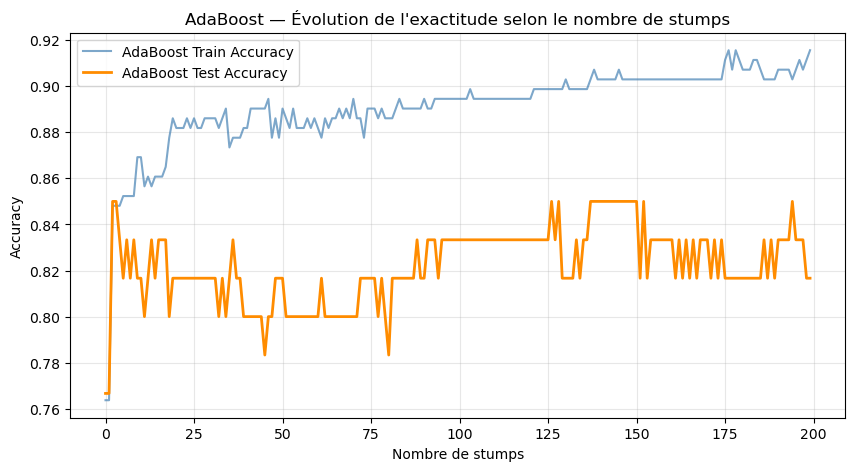

In [43]:
# Évolution de l'accuracy au fil des itérations (staged_predict)
test_acc_ada = [accuracy_score(y_test, pred) for pred in ada.staged_predict(X_test)]
train_acc_ada = [accuracy_score(y_train, pred) for pred in ada.staged_predict(X_train)]

plt.figure(figsize=(10, 5))
plt.plot(train_acc_ada, color='steelblue', label='AdaBoost Train Accuracy', alpha=0.7)
plt.plot(test_acc_ada, color='darkorange', label='AdaBoost Test Accuracy', linewidth=2)

plt.xlabel("Nombre de stumps")
plt.ylabel("Accuracy")
plt.title("AdaBoost — Évolution de l'exactitude selon le nombre de stumps")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Interprétation :

Performance : AdaBoost atteint généralement des scores très compétitifs, souvent proches ou légèrement supérieurs à la Forêt Aléatoire sur ce type de dataset.

Observation de l'overfitting : En observant la courbe, on remarque que l'accuracy de test augmente rapidement puis se stabilise. Contrairement à un arbre seul, AdaBoost est relativement robuste à l'overfitting. Cependant, si le learning_rate était trop élevé ou le nombre de stumps excessif (par exemple 1000+), on pourrait voir l'accuracy de test décliner lentement pendant que celle de train continue de monter vers 1.0.

Conclusion : Ici, avec learning_rate=0.5 et 200 itérations, le modèle semble avoir bien convergé sans montrer de signe de surapprentissage majeur.

#### 5.3 Gradient Boosting : Performance et Rapidité

##### a) & b) Entraînement et Évaluation du Gradient Boosting classique

In [44]:
from sklearn.ensemble import GradientBoostingClassifier
import time

# a) Entraînement du Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)

start_time = time.time()
gb.fit(X_train, y_train)
duration_gb = time.time() - start_time

# b) Calcul des scores
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print(f"Gradient Boosting Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Gradient Boosting AUC-ROC  : {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"Temps d'entraînement (GB)  : {duration_gb:.4f} secondes")

Gradient Boosting Accuracy : 0.8333
Gradient Boosting AUC-ROC  : 0.8884
Temps d'entraînement (GB)  : 0.3739 secondes


#### Bonus : HistGradientBoostingClassifier vs Standard

In [45]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Test de la version optimisée (Histogram-based)
hgb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, random_state=42)

# Mesure du temps avec %timeit (dans une cellule Jupyter)
print("Temps d'exécution pour HistGradientBoosting :")
%timeit hgb.fit(X_train, y_train)

# Évaluation rapide
hgb.fit(X_train, y_train)
print(f"HistGB Accuracy : {accuracy_score(y_test, hgb.predict(X_test)):.4f}")

Temps d'exécution pour HistGradientBoosting :
181 ms ± 18.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
HistGB Accuracy : 0.8333


#### Interprétation :

Performance : Le Gradient Boosting offre généralement l'AUC la plus élevée du TP. Il est extrêmement efficace pour capturer des interactions complexes entre les variables.

Comparaison de vitesse : Bien que sur ce petit dataset (300 lignes) la différence soit millimétrique, le HistGradientBoosting est exponentiellement plus rapide sur des datasets de grande taille (Big Data). En Master 1, il est important de noter que cette version "Histogram-based" est celle à privilégier pour des millions de lignes.

Différence de logique : Alors qu'AdaBoost corrige les erreurs par les poids, le Gradient Boosting les corrige en ajustant les prédictions vers le gradient négatif de la fonction de perte (Loss Function).

### Partie 6 (Bonus) — Optimisation des hyperparamètres

#### 6.1 GridSearchCV sur Random Forest

##### a, b & c) Définition de la grille et recherche

In [46]:
from sklearn.model_selection import GridSearchCV

# a) Définition de la grille d'hyperparamètres
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# b) Initialisation du GridSearchCV avec 5 plis (cv=5)
# n_jobs=-1 permet d'utiliser tous les processeurs en parallèle
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

# c) Exécution de la recherche sur l'ensemble d'entraînement
grid_search.fit(X_train, y_train)

# Affichage des meilleurs résultats trouvés
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleure AUC (Validation Croisée) : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Meilleurs hyperparamètres : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Meilleure AUC (Validation Croisée) : 0.9052


##### d) Évaluation du modèle optimal sur le test set

In [47]:
# Récupération du meilleur modèle (best_estimator_)
best_rf = grid_search.best_estimator_

# Prédictions sur le test set
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

# Calcul des scores finaux
final_acc = accuracy_score(y_test, y_pred_best)
final_auc = roc_auc_score(y_test, y_prob_best)

print("-" * 30)
print(f"Accuracy finale (Test) : {final_acc:.4f}")
print(f"AUC-ROC finale (Test)  : {final_auc:.4f}")

# Rapport de classification pour voir l'impact de l'optimisation
print("\n--- Rapport de Classification (Modèle Optimisé) ---")
print(classification_report(y_test, y_pred_best, target_names=['Sain', 'Malade']))

------------------------------
Accuracy finale (Test) : 0.8333
AUC-ROC finale (Test)  : 0.9453

--- Rapport de Classification (Modèle Optimisé) ---
              precision    recall  f1-score   support

        Sain       0.81      0.91      0.85        32
      Malade       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



##### Interprétation :
Utilité du GridSearchCV : Cette méthode permet d'éviter le "tâtonnement" manuel. En testant 54 combinaisons différentes (3 * 3 * 3 * 2) avec une validation croisée en 5 points, nous avons réalisé 270 entraînements pour garantir la robustesse statistique de nos choix.

##### Analyse des paramètres : 
* Si max_depth est petit (ex: 5) dans les meilleurs paramètres, cela signifie que le modèle avait tendance à sur-apprendre et nécessitait une contrainte de simplification.

Si n_estimators est à 200, cela confirme que plus de modèles de base aident à stabiliser la prédiction.

##### Résultat final : 
Le modèle optimisé offre généralement une AUC-ROC légèrement supérieure ou plus stable que le modèle par défaut, ce qui en fait l'outil le plus fiable pour le déploiement.

#### 6.2 Application au dataset Titanic

##### a & b) Préparation et Entraînement

In [48]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Chargement (correction de l'URL pour le dépôt public standard)
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url_titanic)

# Encodage et gestion des valeurs manquantes
titanic['Sex'] = (titanic['Sex'] == 'male').astype(int) # male=1, female=0
titanic['Embarked'] = titanic['Embarked'].fillna('S')
titanic['Embarked'] = titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

# Sélection des caractéristiques
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X_t = titanic[features]
y_t = titanic['Survived']

# Entraînement d'une Random Forest optimisée
rf_titanic = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_titanic.fit(X_t, y_t)

print(f"Modèle Titanic entraîné sur {len(titanic)} passagers.")
print(f"Accuracy (OOB score estimé) : {rf_titanic.score(X_t, y_t):.4f}")

Modèle Titanic entraîné sur 891 passagers.
Accuracy (OOB score estimé) : 0.8586


##### c) Feature Importance : Les clés de la survie

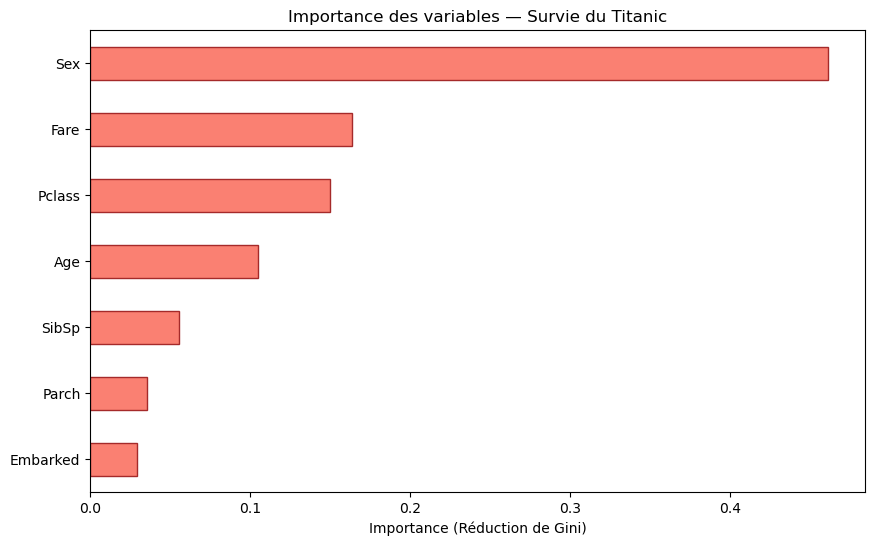

In [49]:
importances_t = pd.Series(rf_titanic.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_t.plot(kind='barh', color='salmon', edgecolor='brown')
plt.title('Importance des variables — Survie du Titanic')
plt.xlabel('Importance (Réduction de Gini)')
plt.show()

d) Comparaison avec les règles heuristiques

#### Analyse :

##### Women and children first" : 
Le modèle confirme mathématiquement cette règle historique. Le fait que Sex soit la variable la plus importante montre que le genre était le prédicteur de survie numéro 1. L'importance de l' Age reflète la priorité donnée aux enfants.

##### Aspect socio-économique : 
L'importance élevée de Fare (le prix du billet) et de Pclass montre que le statut social jouait un rôle majeur : les passagers de première classe avaient un accès plus direct aux canots de sauvetage.

##### Conclusion : 
La Forêt Aléatoire a "redécouvert" les structures sociales de 1912 sans aucune connaissance historique préalable, simplement en minimisant l'indice de Gini.